In [18]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""
#TASK 1: Create a 5x5 matrix where border elements are 1 and interior is 0

import numpy as np
matrix = np.ones((5,5))
matrix[1:-1, 1:-1] = 0
print(matrix)

#TASK 2:  Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized_data = (random_data - random_data.mean(axis = 0))/random_data.std(axis = 0)

print("\nColumn means:" )
print(normalized_data.mean(axis = 0))

print("\nColumn standard deviations: ")
print(normalized_data.std(axis = 0))


# TASK 3: Implement linear regression solution using normal equatio
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("\nTrue theta: ")
print(true_theta)
print("\nEstimated theta: ")
print(theta_hat)


[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Column means:
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

Column standard deviations: 
[1. 1. 1.]

True theta: 
[ 2.5 -1.2  3.7]

Estimated theta: 
[ 2.51723721 -1.19783796  3.72399266]


In [19]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# TASK 1: Data Cleaning and Exploration
print(df.info())
print("\nMissing values: ")
print(df.isnull().sum())

df['exam_score'] = (df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))) #replace missing exam scores with mean score of student's major

df['hours_studied'] = (df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))) #replace missing hours studied with student's year

print("\n Missing values After Cleaning: ")
print(df.isnull().sum())



# TASK 2: Analysis

avg_score_major = df.groupby('major')['exam_score'].mean()
print("\nAverage score by major: ")
print(avg_score_major)

best_major = avg_score_major.idxmax() #major with highest average score

print("\nMajor with Highest Average Score:")
print(best_major)

correlation = df['hours_studied'].corr(df['exam_score'])

print("\nCorrelation:")
print(correlation)

# Performance categories

conditions = [
    df['exam_score'] > 90,
    (df['exam_score'] > 80) & (df['exam_score'] <= 90),
    (df['exam_score'] >= 70) & (df['exam_score'] <= 80),
    df['exam_score'] < 70
]

choices = [
    'Excellent',
    'Good',
    'Average',
    'Needs Improvement'
]

df['performance'] = np.select(
    conditions,
    choices,
    default='Average'
)

print(df[['exam_score', 'performance']].head())


# TASK 3: Advanced Analysis
summary = (df.groupby(['major', 'year']).agg(students_no=('student_id', 'count'), avg_score=('exam_score', 'mean'), avg_hours=('hours_studied', 'mean')))

print("\nSummary Table:")
print(summary)

top_students = (
    df.nlargest(10, 'exam_score')
)

print("\nTop 10 Students:")
print(top_students[['student_id', 'exam_score']])

pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table:")
print(pivot)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

Missing values: 
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

 Missing values After Cleaning: 
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64

Aver

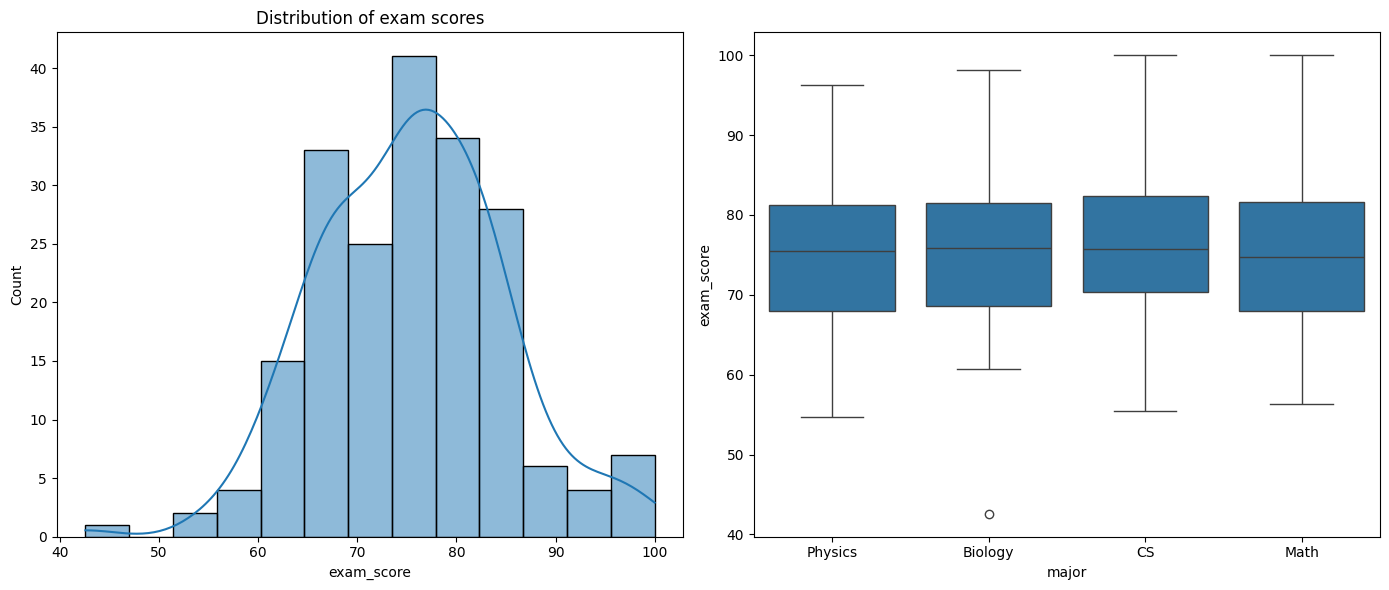

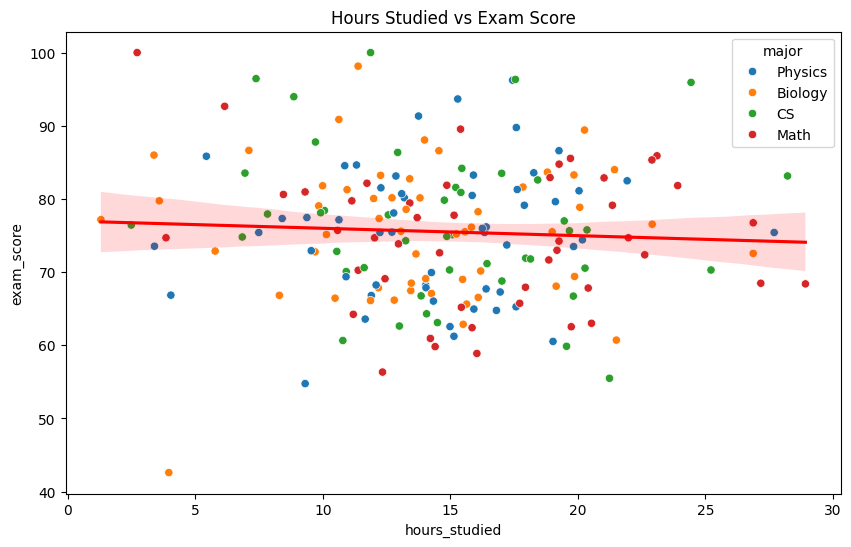

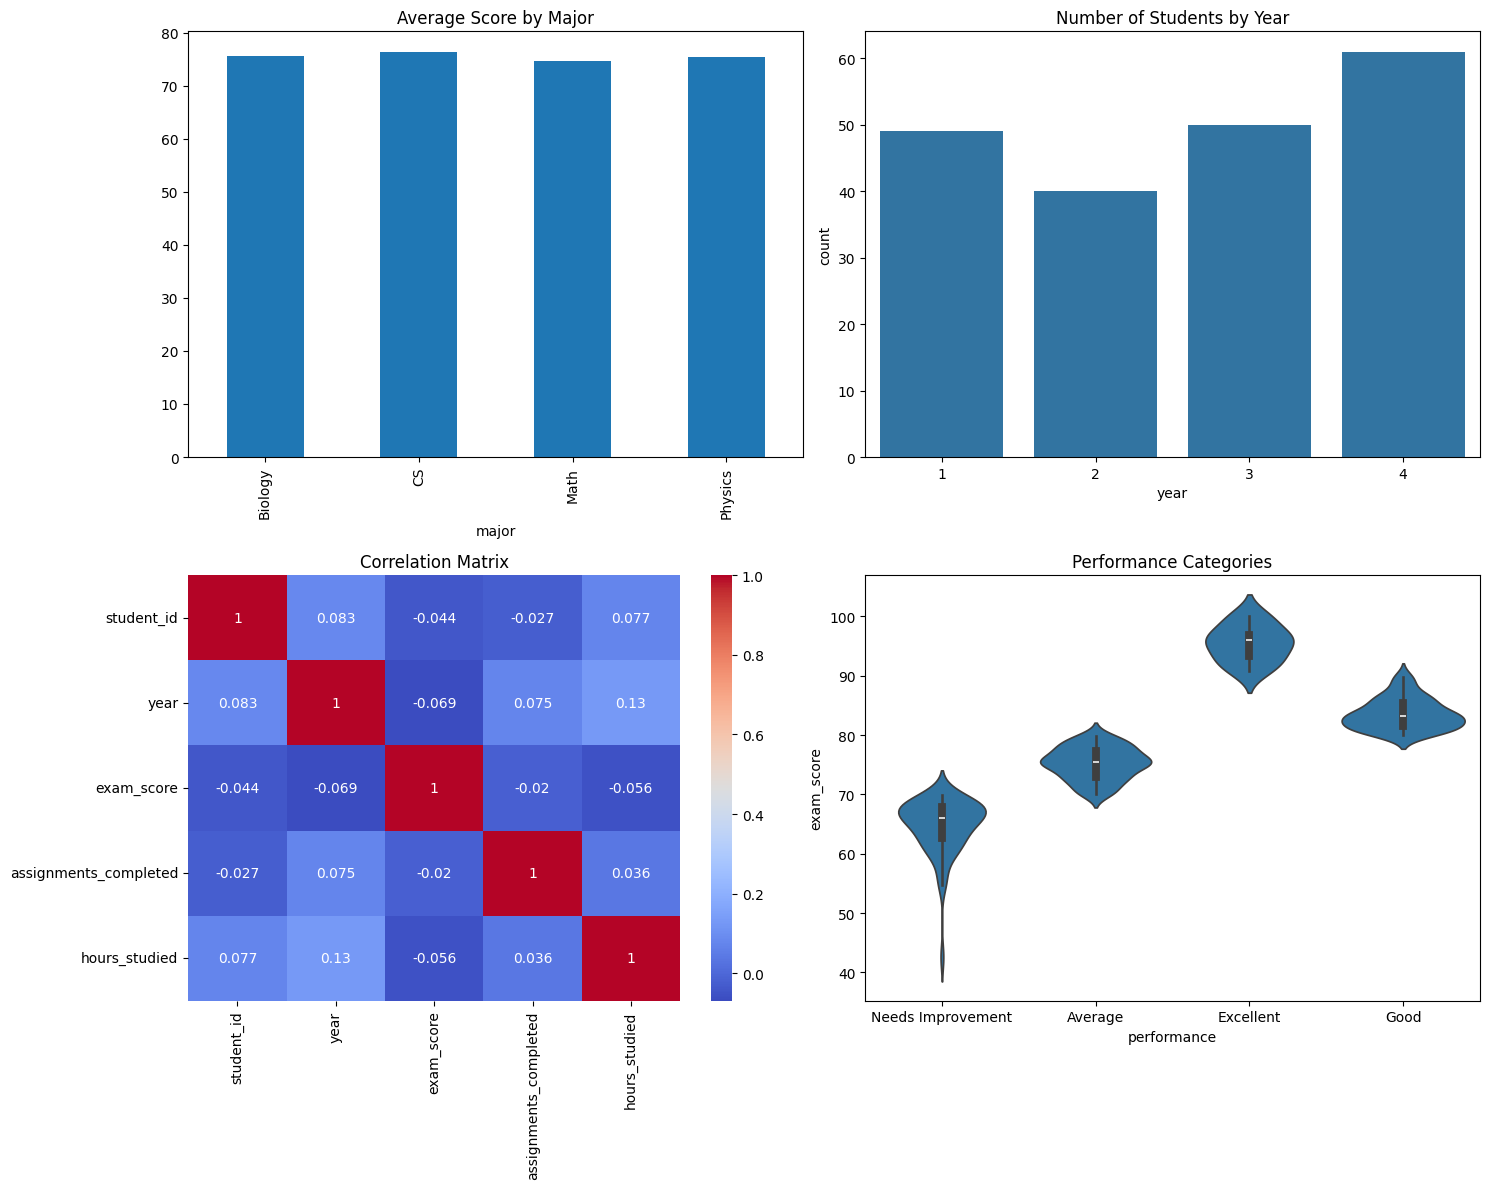

In [20]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Continue using the df from Exercise 5
#TASK 1: Distribution Visualization
fig, axes = plt.subplots(1,2, figsize = (14,6))
sns.histplot(df['exam_score'], kde = True, ax = axes[0])

axes[0].set_title("Distribution of exam scores")

sns.boxplot(data = df, x = "major", y = 'exam_score', ax = axes[1])

plt.tight_layout()
plt.show()

# TASK 2: Relationship Visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major')

sns.regplot(data=df, x='hours_studied', y='exam_score', scatter=False, color='red')

plt.title('Hours Studied vs Exam Score')
plt.show()


# TASK 3: Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Bar Chart
avg_scores = df.groupby('major')['exam_score'].mean()

avg_scores.plot(kind='bar', ax=axes[0,0])

axes[0,0].set_title('Average Score by Major')

# Count Plot
sns.countplot( data=df, x='year', ax=axes[0,1])

axes[0,1].set_title('Number of Students by Year')

# Heatmap
numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap( numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[1,0])

axes[1,0].set_title('Correlation Matrix')

# Violin Plot
sns.violinplot( data=df, x='performance', y='exam_score', ax=axes[1,1])

axes[1,1].set_title('Performance Categories')

plt.tight_layout()
plt.show()

           customers    avg_income     avg_clv      total_clv
age_group                                                    
18-25             81  50634.018330  718.371170   58188.064760
26-35             73  48747.148046  747.738562   54584.915035
36-50            160  48516.895668  732.796612  117247.457917
51-70            186  50713.163384  762.693498  141860.990683

Top 10% Customers:
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663     36-50  
24  1283.421714     36-50  
57  1

/tmp/ipykernel_7985/3920293584.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = (customers.groupby('age_group').agg(customers=('age', 'count'), avg_income=('income', 'mean'), avg_clv=('CLV', 'mean'), total_clv=('CLV', 'sum')))


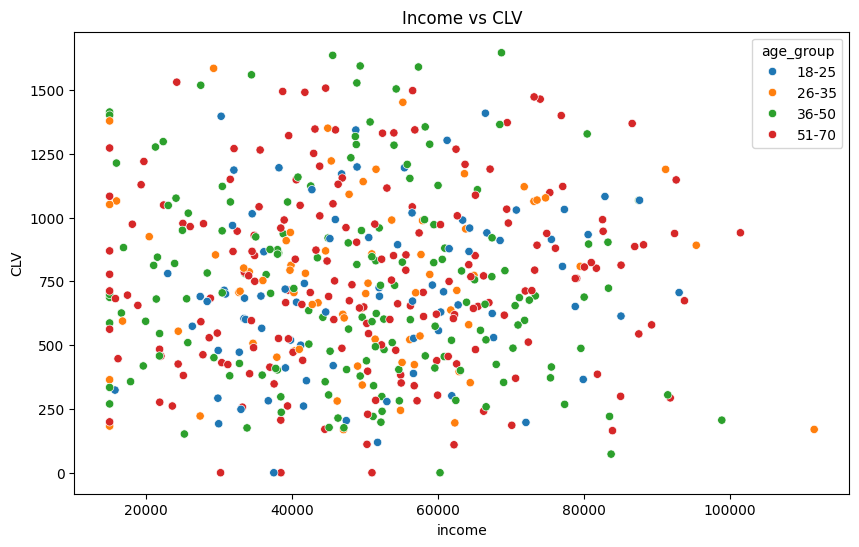

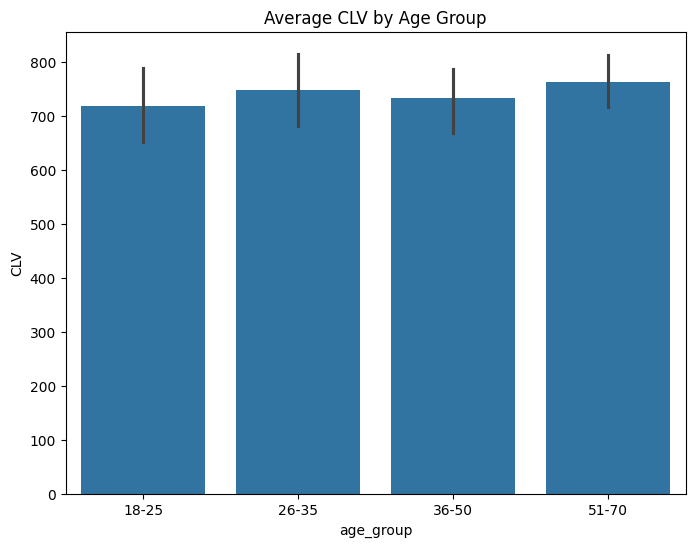

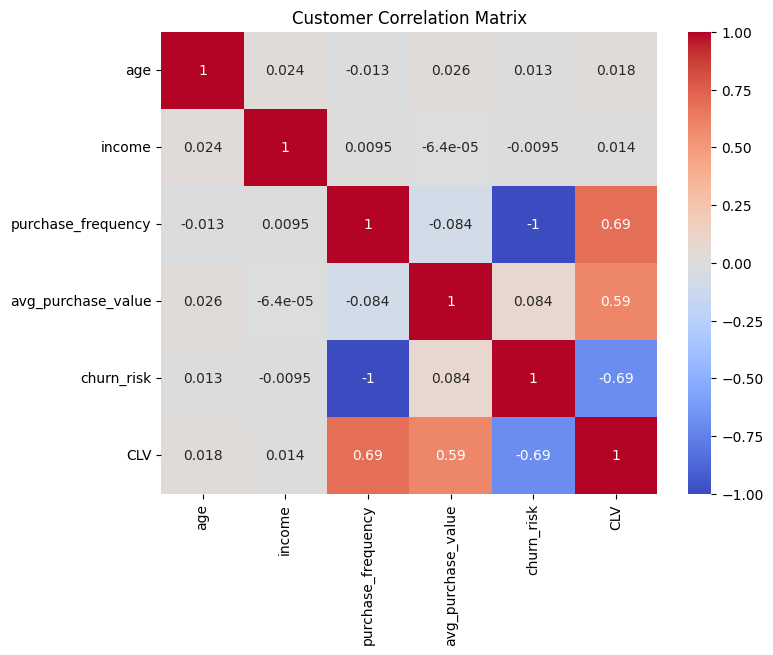

'A key finding is that purchase frequency is a key contributor to CLV, showing a much higher correlation than income level'

In [21]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Customer lifetime value
max_freq = customers['purchase_frequency'].max()

customers['churn_risk'] = (1 - customers['purchase_frequency'] / max_freq)

customers['CLV'] = (customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk']))


# Age Groups
customers['age_group'] = pd.cut(customers['age'], bins=[18,25,35,50,70], labels=['18-25', '26-35', '36-50', '51-70'], include_lowest=True)


# Group Statistics
age_summary = (customers.groupby('age_group').agg(customers=('age', 'count'), avg_income=('income', 'mean'), avg_clv=('CLV', 'mean'), total_clv=('CLV', 'sum')))
print(age_summary)


# Top 10%
threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= threshold]

print("\nTop 10% Customers:")
print(top_customers.head())


# Visualization 1
plt.figure(figsize=(10,6))

sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group')

plt.title('Income vs CLV')
plt.show()


# Visualization 2
plt.figure(figsize=(8,6))

sns.barplot(
    data=customers,
    x='age_group',
    y='CLV'
)

plt.title('Average CLV by Age Group')
plt.show()


# Visualization 3
plt.figure(figsize=(8,6))

sns.heatmap(
    customers.select_dtypes(include=np.number)
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Customer Correlation Matrix')
plt.show()

'''A key finding is that purchase frequency is a key contributor to CLV, showing a much higher correlation than income level'''